In [26]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as ssb

In [27]:
#import data
data = pd.read_csv("/content/Malware Data/DynamicMalwareMatrix2.csv")
data.head()

,labels,00,0000,0000000,000000000046,00021401,00c04fc295ee,01,0156250,02,...,windowsruntime,winevt,wmiprvse,working,wow6432node,write,writefile,xaml,xls,zip
0,1,11,0,5,0,0,0,1,6,0,...,0,0,0,36,0,0,0,0,0,0
1,1,0,0,1,0,0,0,0,0,0,...,0,0,0,19,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,3,0,...,0,0,0,8,0,0,0,0,0,0
3,1,52,0,2,0,0,0,2,0,6,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
data.shape

(34371, 501)

In [29]:
#Data Processing
# dividing data input and output x, y for input and outputs respectively
X = data.drop("labels",axis = 1)
y = data["labels"]

In [30]:
# split data for training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,random_state =42, test_size=0.3)

In [31]:
scores =[]

In [32]:
# modelling from sklearn lib using Desision tree algo
from sklearn.tree import DecisionTreeClassifier
Treemodel = DecisionTreeClassifier(random_state=42)

In [33]:
# model training
tree = Treemodel.fit(X_train, y_train)

In [34]:
# predicting values
y_pred = tree.predict(X_test)
test_compare = pd.DataFrame({'y_test': y_test,'y_pred': y_pred})
test_compare.head(10)
# the data set is label as 1 for goodware and -1 for malware

,y_test,y_pred
32669,-1,-1
8480,1,1
27209,-1,-1
34013,-1,-1
15272,1,1
4990,1,1
8139,1,1
12536,1,1
24437,-1,-1
28379,-1,-1


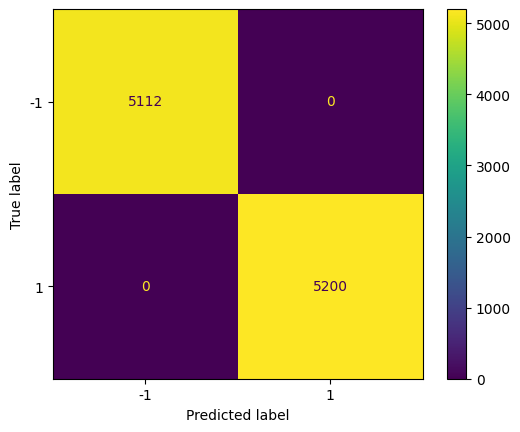

In [35]:
# Evaluating Results of Decision Tree Model
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(tree, X_test, y_pred)

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
print('Classification Report', classification_report(y_test, y_pred))

Classification Report               precision    recall  f1-score   support

          -1       1.00      1.00      1.00      5104
           1       1.00      1.00      1.00      5208

    accuracy                           1.00     10312
   macro avg       1.00      1.00      1.00     10312
weighted avg       1.00      1.00      1.00     10312



In [38]:
print('Score', tree.score(X_test, y_test))
scores.append(tree.score(X_test, y_test))

Score 0.997478665632273


In [41]:
# logistic regression
# standard scaling
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [42]:
#import model
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=500)

In [43]:
log = logmodel.fit(X_train, y_train)

In [44]:
#performing predictions on test set
y_pred = log.predict(X_test)
test_compare = pd.DataFrame({'y_test': y_test,'y_pred': y_pred})
test_compare.head(10)

,y_test,y_pred
32669,-1,-1
8480,1,1
27209,-1,-1
34013,-1,-1
15272,1,1
4990,1,1
8139,1,1
12536,1,1
24437,-1,-1
28379,-1,-1


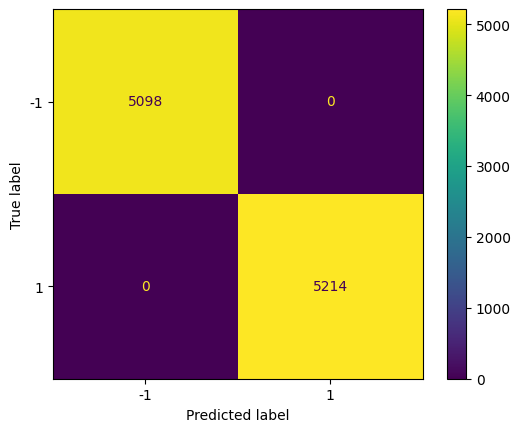

In [45]:
#evaluvation on the logistic regression model
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(log, X_test, y_pred)

In [46]:
print('Score', log.score(X_test, y_test))
scores.append(log.score(X_test, y_test))

Score 0.9994181536074477
